# 3o Lab de PSD (notebook para preencher com os resultados)

### Número do Grupo : 5

In [ ]:
#
# Primeiro vamos importar as bibliotecas necessárias
#
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import convolve, correlate

## 1. Derivada de sinais 1D

### Estude os códigos abaixo

Vamos primeiro definir uma função f(x)=x**2, chamada fx

Text(0, 0.5, '$f(x)=x^2$')

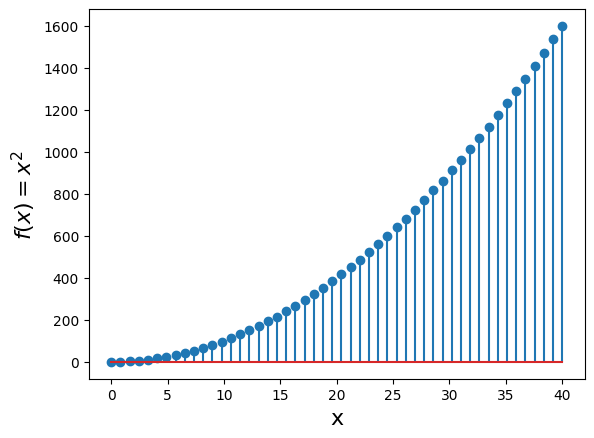

In [ ]:
#
# Definição do eixo x
# 50 amostras entre 0 e 40
#
x = np.linspace(0, 40, 50)

#
# Obtendo os valores da função f(x)
#
fx = x**2

#
# Desenha o gráfico e insere labels
#
plt.stem(x, fx)
plt.xlabel('x', size=16)
plt.ylabel('$f(x)=x^2$', size=16)

#### Cálculo da derivada de fx:

[ 0.81632653  2.44897959  4.08163265  5.71428571  7.34693878  8.97959184
 10.6122449  12.24489796 13.87755102 15.51020408 17.14285714 18.7755102
 20.40816327 22.04081633 23.67346939 25.30612245 26.93877551 28.57142857
 30.20408163 31.83673469 33.46938776 35.10204082 36.73469388 38.36734694
 40.         41.63265306 43.26530612 44.89795918 46.53061224 48.16326531
 49.79591837 51.42857143 53.06122449 54.69387755 56.32653061 57.95918367
 59.59183673 61.2244898  62.85714286 64.48979592 66.12244898 67.75510204
 69.3877551  71.02040816 72.65306122 74.28571429 75.91836735 77.55102041
 79.18367347]


Text(0, 0.5, '$\\Delta f/\\Delta x\\approx 2x$')

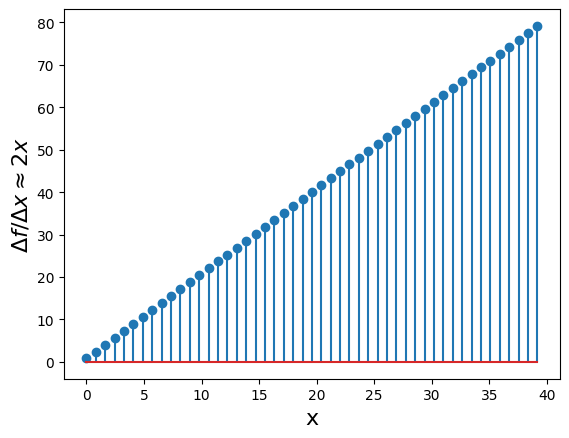

In [ ]:
#
# A derivada de 1a ordem do sinal pode ser calculada por diferenças
# como indicado no código comentado abaixo
#
dx = x[1]-x[0]
dfx = np.zeros(len(fx)-1)
for i in range(len(fx)-1):
    dfx[i] = (fx[i+1] - fx[i])/dx
print(dfx)
#
# Desenha o gráfico e insere labels
#
plt.stem(x[:-1], dfx)
plt.xlabel('x', size=16)
plt.ylabel(r'$\Delta f/\Delta x\approx 2x$', size=16)

# PROBLEMA 1

## Parte A

Reescreva o código acima substituindo o cálculo da "derivada por diferenças" usando um "filtro derivativo" e a operação de convolução ou correlação cruzada

[ 0.00000000e+00  8.16326531e-01  2.44897959e+00  4.08163265e+00
  5.71428571e+00  7.34693878e+00  8.97959184e+00  1.06122449e+01
  1.22448980e+01  1.38775510e+01  1.55102041e+01  1.71428571e+01
  1.87755102e+01  2.04081633e+01  2.20408163e+01  2.36734694e+01
  2.53061224e+01  2.69387755e+01  2.85714286e+01  3.02040816e+01
  3.18367347e+01  3.34693878e+01  3.51020408e+01  3.67346939e+01
  3.83673469e+01  4.00000000e+01  4.16326531e+01  4.32653061e+01
  4.48979592e+01  4.65306122e+01  4.81632653e+01  4.97959184e+01
  5.14285714e+01  5.30612245e+01  5.46938776e+01  5.63265306e+01
  5.79591837e+01  5.95918367e+01  6.12244898e+01  6.28571429e+01
  6.44897959e+01  6.61224490e+01  6.77551020e+01  6.93877551e+01
  7.10204082e+01  7.26530612e+01  7.42857143e+01  7.59183673e+01
  7.75510204e+01  7.91836735e+01 -1.96000000e+03]
[ 0.00000000e+00  6.66389005e-01  1.99916701e+00  3.33194502e+00
  4.66472303e+00  5.99750104e+00  7.33027905e+00  8.66305706e+00
  9.99583507e+00  1.13286131e+01  1.2661

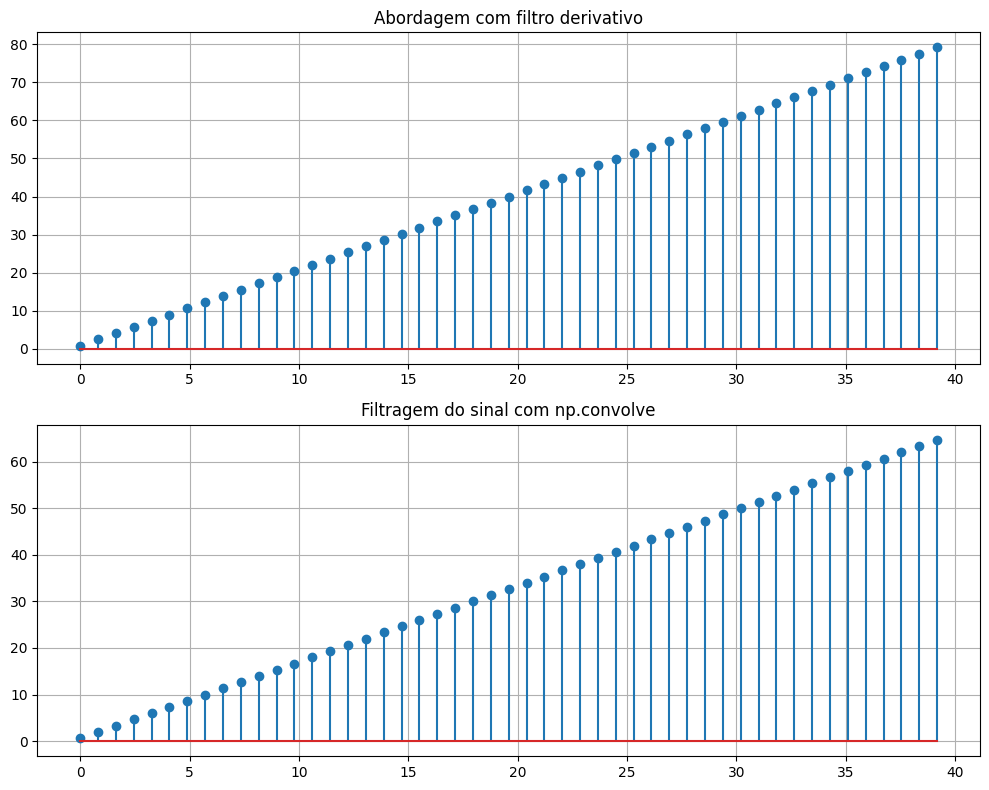

In [ ]:
#
# Definir o filtro derivativo de 1a ordem de 2 elementos
#
# -> INSERIR SEU CÓDIGO AQUI!
w = np.array([1, -1])

# Função convolução
def conv(x, h):
    N = len(x)
    M = len(h)

    result = [0] * (N + M - 1)

    for i in range(N):
        for j in range(M):
            result[i + j] += x[i] * h[j]

    return result

# Usando filtro derivativo e a operação de convolução
dx = x[1] - x[0]
result = conv(fx, w) / dx
print(result)

#
# Usar o método "numpy.correlate(a, v, mode='valid')" ou "numpy.convolve(a, v, mode='full')"
# para realizar a filtragem do sinal
#
# -> INSERIR SEU CÓDIGO AQUI!
result2 = np.convolve(fx, w, mode='full')
print(result2)

#
# Desenha o gráfico e insere labels
#

fig = plt.figure(figsize=(10,8))

sub0 = fig.add_subplot(211)
sub0.set_title('Abordagem com filtro derivativo')
sub0.stem(x[:-1], result[1:-1])
sub0.grid(True)

sub1 = fig.add_subplot(212)
sub1.set_title('Filtragem do sinal com np.convolve')
sub1.stem(x[:-1], result2[1:-1])
sub1.grid(True)

fig.tight_layout()
plt.show()

## Parte B

Usando o método numpy.correlate(a, v, mode='valid') determine a derivada de 1a ordem da função seno definida no intervalo de 0 a $4\pi$

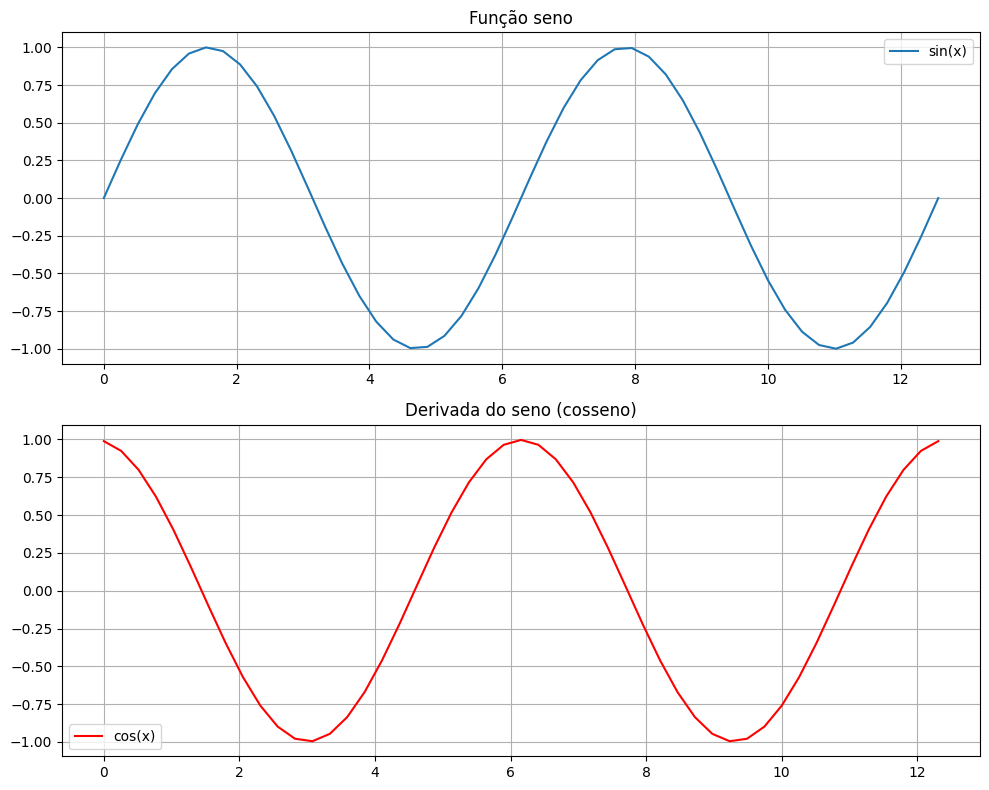

In [ ]:
#
# Defina o eixo x no intervalo indicado acima com um total de N=50 amostras
#
# -> INSERIR SEU CÓDIGO AQUI!
x_axis = np.linspace(0, 4 * np.pi, 50)
dx = x_axis[1] - x_axis[0]

#
# Defina a função seno -> use a função np.sin()
#
# -> INSERIR SEU CÓDIGO AQUI!
func = np.sin(x_axis)

#
# Derivada da função seno
#
# -> INSERIR SEU CÓDIGO AQUI!
w = np.array([-1, 1])
dfunc = np.correlate(func, w, mode='valid') / dx

axis = x_axis[:-1]

#
# Plotar usando "subplot" as funções seno e sua derivada
#
# -> INSERIR SEU CÓDIGO AQUI!
fig = plt.figure(figsize=(10,8))

sub0 = fig.add_subplot(211)
sub0.set_title('Função seno')
sub0.plot(x_axis, func, label='sin(x)')
sub0.grid(True)
sub0.legend()

sub1 = fig.add_subplot(212)
sub1.set_title('Derivada do seno (cosseno)')
sub1.plot(axis, dfunc, 'r', label='cos(x)')
sub1.grid(True)
sub1.legend()

fig.tight_layout()
plt.show()

## Parte C

Repita o experimento acima mas agora adicionando ruído à função f(x) (função seno definida anteriormente). Para isso, utilize o seguinte trecho de código após a determinação dos valores de f(x).

In [ ]:
mu = 0.0                               # média zero
sigma = 0.3                            # desvio padrão 0.3
N = 50                                 # número de amostras igual a 50
noise = np.random.normal(mu, sigma, N) # ruído a ser inserido ao sinal
fx_noise = fx + noise

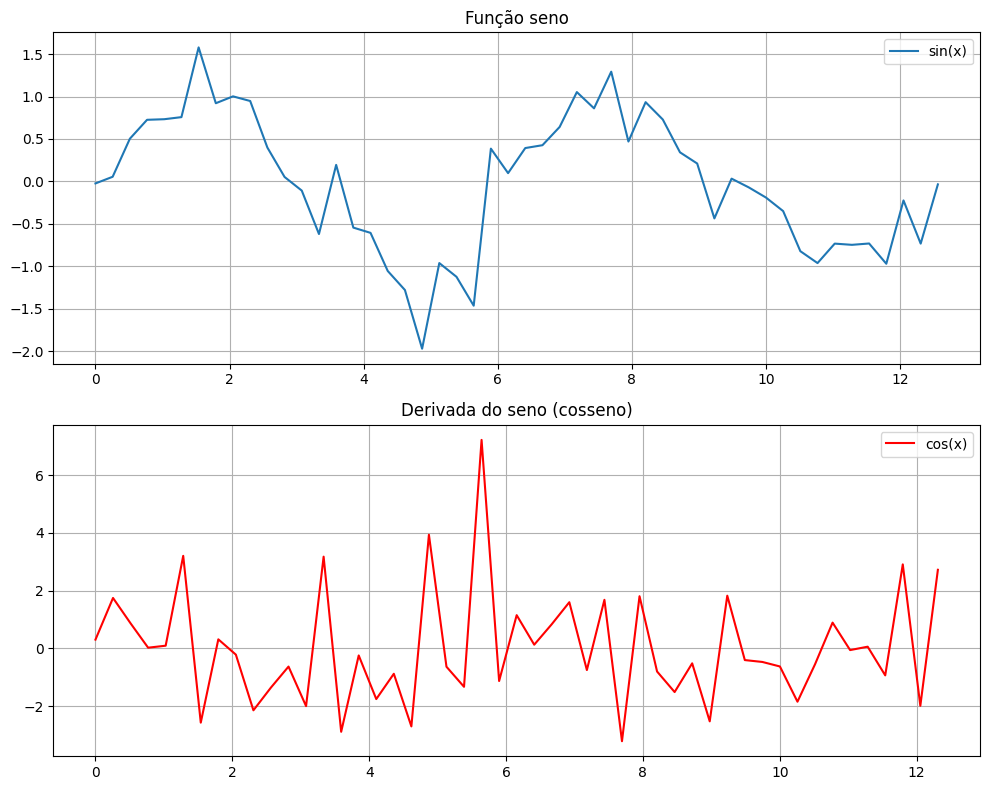

In [ ]:
# -> INSERIR SEU CÓDIGO AQUI!
x_axis = np.linspace(0, 4 * np.pi, 50)
dx = x_axis[1] - x_axis[0]

func = np.sin(x_axis)

mu = 0.0                               # média zero
sigma = 0.3                            # desvio padrão 0.3
N = 50                                 # número de amostras igual a 50
noise = np.random.normal(mu, sigma, N) # ruído a ser inserido ao sinal
fx_noise = func + noise

w = np.array([-1, 1])
dfunc = np.correlate(fx_noise, w, mode='valid') / dx

axis = x_axis[:-1]

#
# Plotar usando "subplot" as funções seno e sua derivada com ruídos
#
# -> INSERIR SEU CÓDIGO AQUI!
fig = plt.figure(figsize=(10,8))

sub0 = fig.add_subplot(211)
sub0.set_title('Função seno')
sub0.plot(x_axis, fx_noise, label='sin(x)')
sub0.grid(True)
sub0.legend()

sub1 = fig.add_subplot(212)
sub1.set_title('Derivada do seno (cosseno)')
sub1.plot(axis, dfunc, 'r', label='cos(x)')
sub1.grid(True)
sub1.legend()

fig.tight_layout()
plt.show()

## Parte D

Usando o filtro gaussiano 1D dado abaixo, realize a convolução do filtro com o sinal fx_noise (fx + noise) e a seguir plote, usando "subplot", os sinais antes e depois da convolução.

OBS: O valor do parâmetro "S" do filtro representa o tamanho do filtro - use um valor ímpar: S=25, por exemplo.

In [ ]:
#
# Filtro Gaussiano 1D
#
#
def filtro_gaussiano_1d(S):
    sigma = S/(2*3)
    x = np.linspace(-3*sigma, 3*sigma, S)
    y = np.exp(-x**2/(2*sigma**2))
    y = y/np.sum(y)

    return y

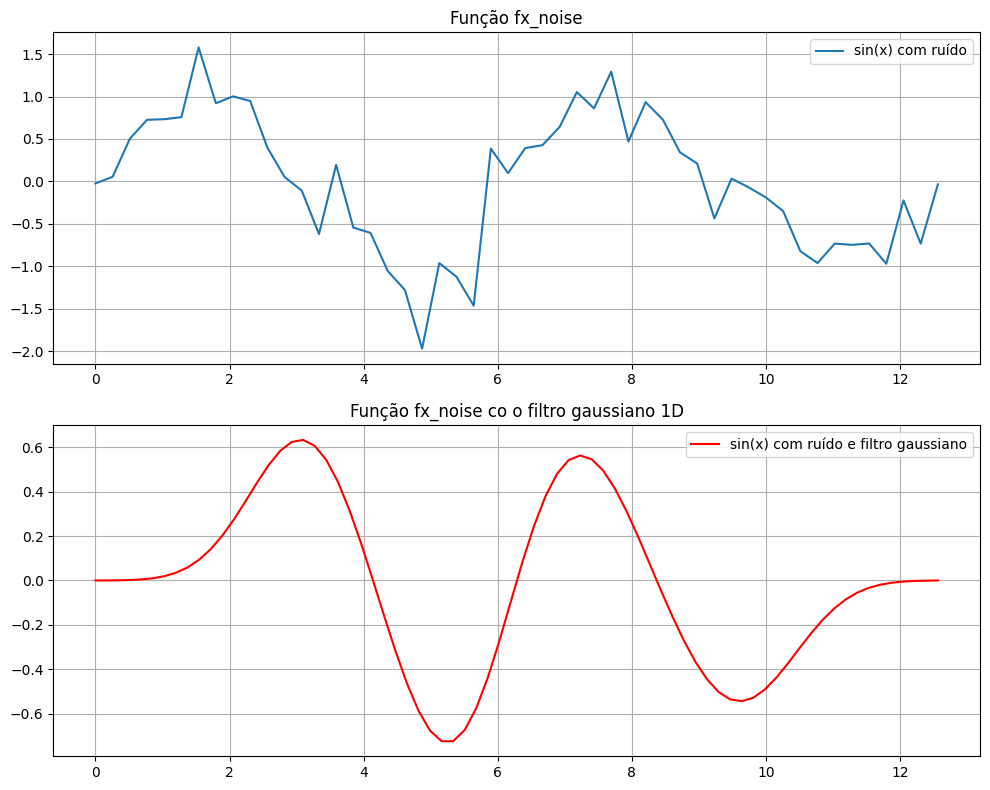

In [ ]:
# -> INSERIR SEU CÓDIGO AQUI!
filtro = filtro_gaussiano_1d(25)
resp = conv(fx_noise, filtro)

# Gerar novo eixo x para resultado da convolução (tamanho expandido)
axis = np.linspace(0, 4 * np.pi, len(resp))

#
# Plotar usando "subplot"
#
# -> INSERIR SEU CÓDIGO AQUI!
fig = plt.figure(figsize=(10,8))

sub0 = fig.add_subplot(211)
sub0.set_title('Função fx_noise')
sub0.plot(x_axis, fx_noise, label='sin(x) com ruído')
sub0.grid(True)
sub0.legend()

sub1 = fig.add_subplot(212)
sub1.set_title('Função fx_noise co o filtro gaussiano 1D')
sub1.plot(axis, resp, 'r', label='sin(x) com ruído e filtro gaussiano')
sub1.grid(True)
sub1.legend()

fig.tight_layout()
plt.show()

## 2. Derivada de imagens

### Estude o código abaixo

### A. Calculando diretamente as diferenças entre pixels adjacentes

Text(0.5, 1.0, 'Derivada em y')

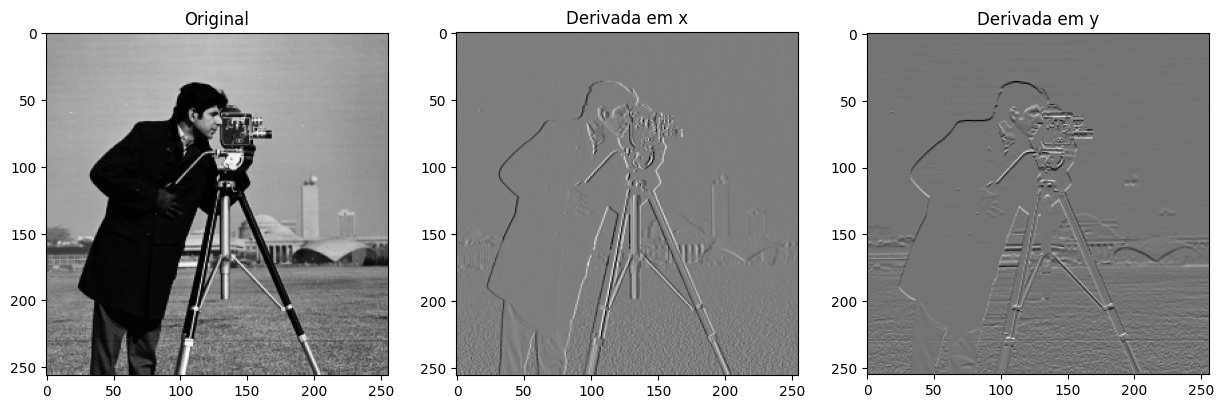

In [ ]:
img = plt.imread('cameraman.tiff')
img = img.astype(int)               # Converte imagem de uint (unsigned int) para int (signed int), pois
                                    # a derivada pode ser negativa
num_rows, num_cols = img.shape

# Derivada na direção x, a imagem resultante possui uma coluna a menos que a original
img_dx = np.zeros((num_rows, num_cols-1))
for row in range(num_rows):
    for col in range(num_cols-1):
        img_dx[row, col] = img[row,col+1] - img[row,col]
# O loop aninhado acima poderia ser substituído por
# img_dx = img[:,1:] - img[:,:-1]
# ou por
# img_dx = np.diff(img, axis=1)

# Derivada na direção y, a imagem resultante possui uma linha a menos que a original
img_dy = np.zeros((num_rows-1, num_cols))
for col in range(num_cols):
    for row in range(num_rows-1):
        img_dy[row, col] = img[row+1,col] - img[row,col]
# O loop aninhado acima poderia ser substituído por
# img_dy = img[1:] - img[:-1]
# ou por
# img_dy = np.diff(img, axis=0)

plt.figure(figsize=[15, 5])
plt.subplot(1, 3, 1)
plt.imshow(img, 'gray')
plt.title('Original')
plt.subplot(1, 3, 2)
plt.imshow(img_dx, 'gray')
plt.title('Derivada em x')
plt.subplot(1, 3, 3)
plt.imshow(img_dy, 'gray')
plt.title('Derivada em y')

Note que a derivada possui tantos valores negativos quantos positivos. Portanto, na visualização acima o valor mais negativo da imagem é mapeado para a cor preta, e o valor mais positivo para a cor branca. Com isso, pixels possuindo derivada zero (regiões uniformes da imagem, como o céu) são mapeados para uma cor intermediária, o cinza.

#### Histograma das imagens:

Text(0.5, 1.0, 'Derivada em y')

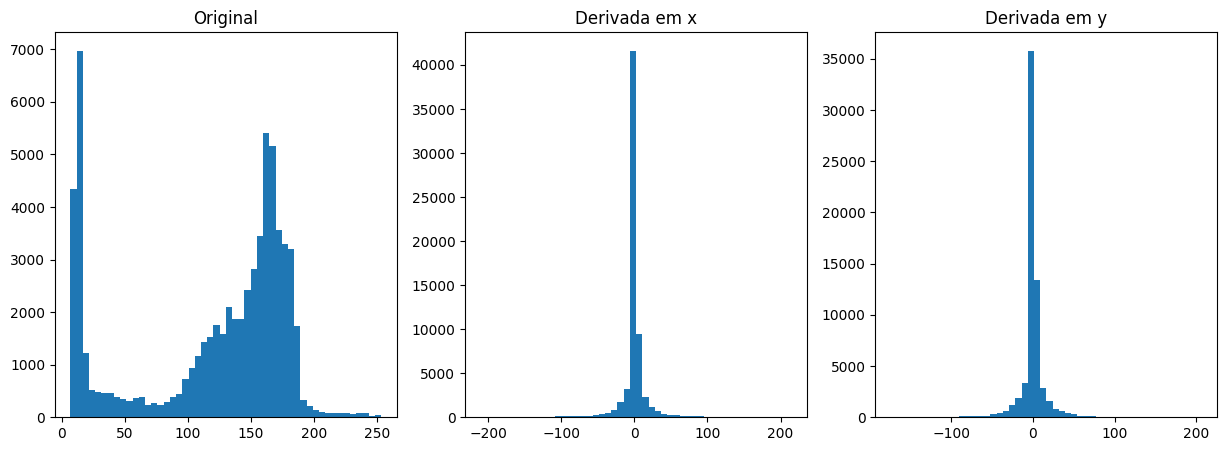

In [ ]:
plt.figure(figsize=[15, 5])
plt.subplot(1, 3, 1)
plt.hist(img.flatten(), 50)
plt.title('Original')
plt.subplot(1, 3, 2)
plt.hist(img_dx.flatten(), 50)
plt.title('Derivada em x')
plt.subplot(1, 3, 3)
plt.hist(img_dy.flatten(), 50)
plt.title('Derivada em y')

#### Magnitude do gradiente

Text(0.5, 1.0, 'Magnitude do gradiente')

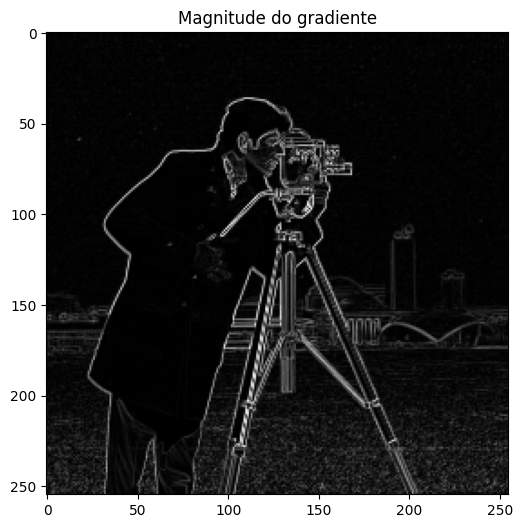

In [ ]:
img_grad_mag = np.zeros((num_rows-1, num_cols-1))
for col in range(num_cols-1):
    for row in range(num_rows-1):
        img_grad_mag[row, col] = np.sqrt(img_dx[row,col]**2+img_dy[row, col]**2)
# Utilizando o numpy, o loop aninhado acima pode ser substituído por
#img_grad_mag = np.sqrt(img_dx[:-1]**2+img_dy[:, :-1]**2)
# Os índices :-1 acima são necessários porque os arrays possuem tamanhos diferentes

plt.figure(figsize=[6,6])
plt.imshow(img_grad_mag, 'gray')
plt.title('Magnitude do gradiente')

# PROBLEMA 2

## Parte A

Reescrever o código acima substituindo o cálculo da derivada por diferenças usado um filtro derivativo simples e a operação de convolução

### Derivada utilizando convolução e o filtro derivada simples

Text(0.5, 1.0, 'Derivada em y')

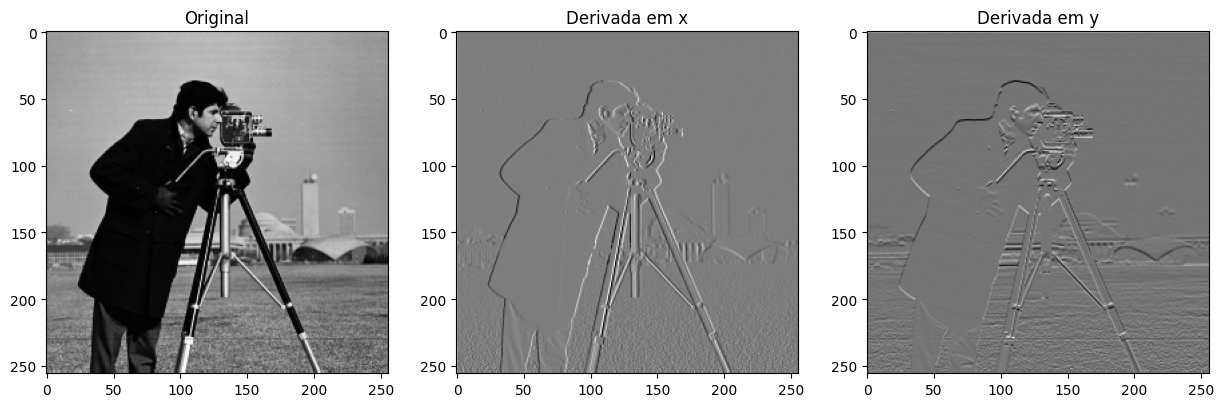

In [ ]:
from scipy.signal import convolve

#
# Filtros derivada
#
wx = np.array([[1,  -1]])
wy = np.array([[1],[-1]])

# -> INSERIR SEU CÓDIGO AQUI!
# Para a função de convolução utilize o parêmtro (mode = 'same')
img_dx_conv = convolve(img, wx, mode='same')
img_dy_conv = convolve(img, wy, mode='same')

plt.figure(figsize=[15, 5])
plt.subplot(1, 3, 1)
plt.imshow(img, 'gray')
plt.title('Original')
plt.subplot(1, 3, 2)
plt.imshow(img_dx_conv, 'gray')
plt.title('Derivada em x')
plt.subplot(1, 3, 3)
plt.imshow(img_dy_conv, 'gray')
plt.title('Derivada em y')

## Parte B

### Derivada utilizando convolução com o filtro de Sobel

Text(0.5, 1.0, 'Derivada em y')

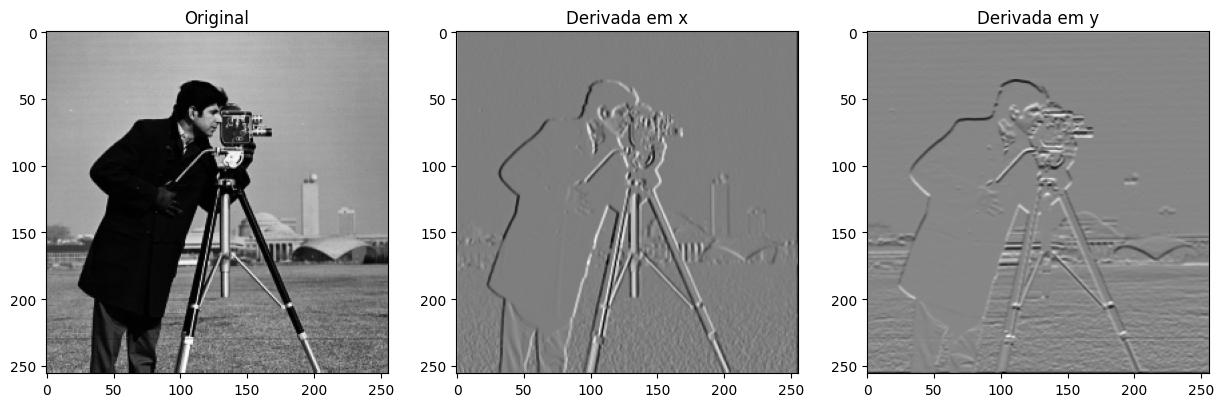

In [ ]:
# Filtros derivada
sx = np.array([[1, 0, -1],
               [2, 0, -2],
               [1, 0, -1]])
sy = sx.transpose()

# -> INSERIR SEU CÓDIGO AQUI!
img_dx_conv_sobel = convolve(img, sx, mode='same')
img_dy_conv_sobel = convolve(img, sy, mode='same')

plt.figure(figsize=[15, 5])
plt.subplot(1, 3, 1)
plt.imshow(img, 'gray')
plt.title('Original')
plt.subplot(1, 3, 2)
plt.imshow(img_dx_conv_sobel, 'gray')
plt.title('Derivada em x')
plt.subplot(1, 3, 3)
plt.imshow(img_dy_conv_sobel, 'gray')
plt.title('Derivada em y')

### Estudar o código abaixo
#### Comparação da magnitude do gradiente entre derivada simples e filtro Sobel

Text(0.5, 1.0, 'Derivada Sobel')

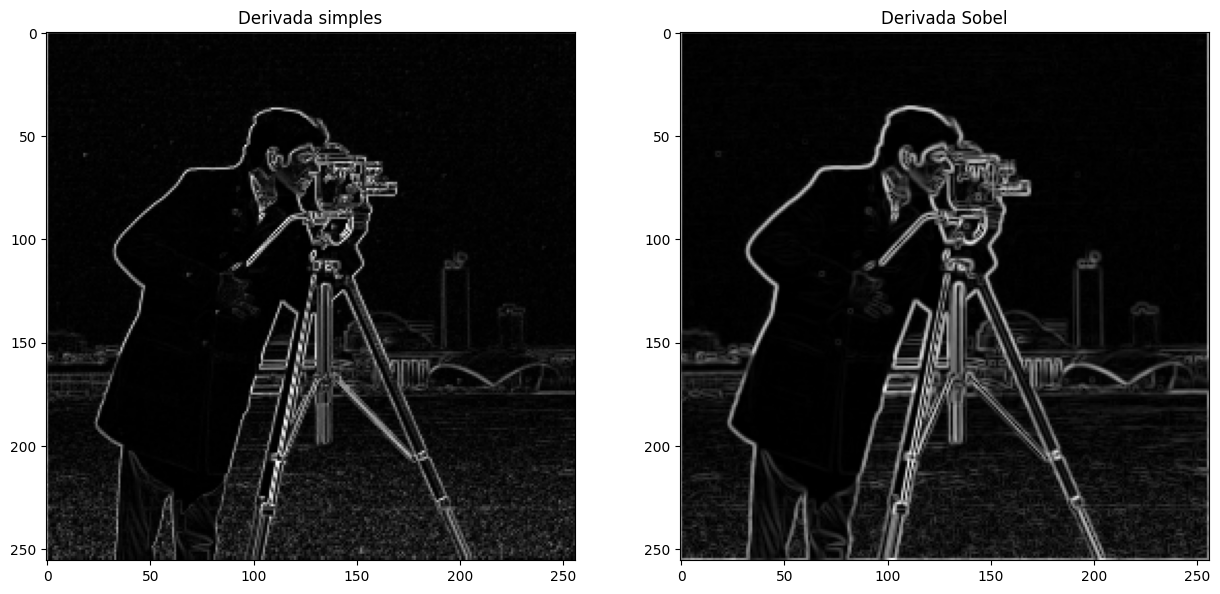

In [ ]:
#
# As variáveis img_dx_conv, img_dy_conv, img_dx_conv_sobel e img_dy_conv_sobel correspondem às derivadas em x e y,
# respectivamente, da imagem do exercício anterior
#
img_grad_mag = np.sqrt(img_dx_conv**2+img_dy_conv**2)
img_grad_mag_sobel = np.sqrt(img_dx_conv_sobel**2+img_dy_conv_sobel**2)
plt.figure(figsize=[15, 7])
plt.subplot(1, 2, 1)
plt.imshow(img_grad_mag, 'gray')
plt.title('Derivada simples')
plt.subplot(1, 2, 2)
plt.imshow(img_grad_mag_sobel, 'gray')
plt.title('Derivada Sobel')


### Estudar o código abaixo
#### Visualização do gradiente em uma dada região da imagem

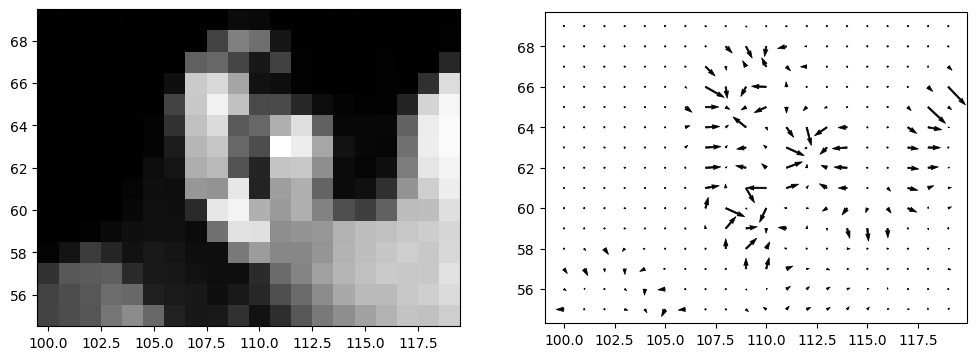

In [ ]:
def view_gradient(img, img_dx, img_dy, region):

    Y, X = np.mgrid[region[0]:region[1], region[2]:region[3]]
    Y = Y[::-1]
    img_region = img[region[0]:region[1], region[2]:region[3]]
    img_dx_region = img_dx[region[0]:region[1], region[2]:region[3]]
    img_dy_region = img_dy[region[0]:region[1], region[2]:region[3]]

    plt.figure(figsize=[12, 6])
    plt.subplot(1, 2, 1, aspect='equal')
    plt.pcolormesh(X, Y, img_region, cmap='gray')
    plt.subplot(1, 2, 2, aspect='equal')
    plt.quiver(X, Y, img_dx_region, -img_dy_region, edgecolor='k', facecolor='k',
               linewidth=.5, scale=3e3)

region = [55,70,100,120]    # [first row, last row, first column, last column]
view_gradient(img, img_dx_conv, img_dy_conv, region)